In [1]:
import sys, os
ROOT_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT_DIR not in sys.path:
    sys.path.insert(0, ROOT_DIR)
    
from data.nuscenes_data import NuscenesData
from nuscenes.nuscenes import NuScenes
from pathlib import Path
import torch

from nuscenes.utils.data_classes import Box
from nuscenes.utils.geometry_utils import points_in_box, view_points
from pyquaternion import Quaternion
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

from utils.box2image import crop_annotation

In [2]:
# Load dataset
data_path = Path("/home/ximeng/Dataset/nuscenes_full_v1_0/")
nusc = NuScenes(version='v1.0-mini', dataroot=data_path)
is_train = 0 # 0: train, 1: val, 2: test
pre_frame = 0
future_frame = 0
dataset = NuscenesData(nusc, is_train, pre_frame, future_frame)
NuScenes_train_dataloader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=True)

Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.503 seconds.
Reverse indexing ...
Done reverse indexing in 0.1 seconds.


In [3]:
for sample in NuScenes_train_dataloader:
    token = sample['token']
    raw_image = sample['raw_images']
    raw_lidar = sample['raw_lidar']
    future_waypoints = sample['future_waypoints']
    pre_waypoints = sample['pre_waypoints']
    cur_waypoint = sample['cur_waypoint']
    velocity = sample['velocity']
    accel = sample['accel']
    yaw_rate = sample['yaw_rate']
    image_paths = sample['image_paths']
    break  # Just to test the data loading

In [4]:
print("Token:", token)
print("Raw Image Shape:", raw_image.shape)
print("Raw Lidar Shape:", raw_lidar.shape)
# print("Future Waypoints Shape:", future_waypoints.shape)
print("Previous Waypoints Shape:", pre_waypoints.shape)
print("Current Waypoint Shape:", cur_waypoint.shape)
print("Velocity Shape:", velocity.shape)
print("Accel Shape:", accel.shape)
print("Yaw Rate Shape:", yaw_rate.shape)
print("Image Paths:", image_paths)

Token: [('b4c279e61abf49bd871ff2ec4b13e115',)]
Raw Image Shape: torch.Size([1, 1, 6, 3, 900, 1600])
Raw Lidar Shape: torch.Size([1, 1, 35000, 4])
Previous Waypoints Shape: torch.Size([1, 0, 3])
Current Waypoint Shape: torch.Size([1, 1, 3])
Velocity Shape: torch.Size([1, 1])
Accel Shape: torch.Size([1, 1, 2])
Yaw Rate Shape: torch.Size([1, 1])
Image Paths: [[('samples/CAM_BACK/n015-2018-11-21-19-38-26+0800__CAM_BACK__1542801000437525.jpg',), ('samples/CAM_BACK_LEFT/n015-2018-11-21-19-38-26+0800__CAM_BACK_LEFT__1542801000447423.jpg',), ('samples/CAM_FRONT_LEFT/n015-2018-11-21-19-38-26+0800__CAM_FRONT_LEFT__1542801000404844.jpg',), ('samples/CAM_FRONT/n015-2018-11-21-19-38-26+0800__CAM_FRONT__1542801000412460.jpg',), ('samples/CAM_FRONT_RIGHT/n015-2018-11-21-19-38-26+0800__CAM_FRONT_RIGHT__1542801000420339.jpg',), ('samples/CAM_BACK_RIGHT/n015-2018-11-21-19-38-26+0800__CAM_BACK_RIGHT__1542801000427894.jpg',)]]


In [5]:
last_lidar = raw_lidar[0][0]

sample_record = nusc.get('sample', sample['token'][-1][0])
lidar_token = nusc.get('sample_data', sample_record['data']['LIDAR_TOP'])
cs_record = nusc.get('calibrated_sensor', lidar_token['calibrated_sensor_token'])
ego_pose = nusc.get('ego_pose', lidar_token['ego_pose_token'])
tp_pair = []
all_bboxes = []

for ann_token in sample_record['anns']:
    # Check visibility
    # nusc.render_annotation(ann_token)
    ann_record = nusc.get('sample_annotation', ann_token)
    visible = ann_record['visibility_token']
    print("Object Visibility:", visible)
    full_label = ann_record['category_name']
    parts = full_label.split('.')
    # Use the second part as the label if it exists, otherwise use the last part
    if len(parts) >= 2:
        label = parts[1]
    else:
        label = parts[-1]
    # Get 3D bounding box
    box = Box(ann_record['translation'], ann_record['size'], Quaternion(ann_record['rotation']))

    # Step 1: global -> ego
    box.translate(-np.array(ego_pose['translation']))
    box.rotate(Quaternion(ego_pose['rotation']).inverse)

    yaw = box.orientation.yaw_pitch_roll[0]
    all_bboxes.append({
        'sample_token': ann_record['token'],
        'instance_token': ann_record['instance_token'],
        'bbox': [*box.center, *box.wlh, yaw],
        'category': ann_record['category_name']
    })
    
    # Extract points within the bounding box
    mask = points_in_box(box, last_lidar[:, :3].T)
    points_in_instance = last_lidar[mask]

    tp_pair.append((label, points_in_instance)) # [(label, pts)]
    break

Object Visibility: 4


In [6]:
# https://github.com/nutonomy/nuscenes-devkit/blob/master/python-sdk/nuscenes/nuscenes.py, render_annotation
def crop_annotation_and_render(nusc, ann_token, sample_record, margin=5, min_ratio=0.8):
    assert 'LIDAR_TOP' in sample_record['data'].keys(), 'Error: No LIDAR_TOP in data, unable to render.'

    # Figure out which camera the object is fully visible in (this may return nothing).
    boxes, cam = [], []
    cams = [key for key in sample_record['data'].keys() if 'CAM' in key]
    for cam in cams:
        _, boxes, _ = nusc.get_sample_data(sample_record['data'][cam], box_vis_level=1, selected_anntokens=[ann_token])
        if len(boxes) > 0:
            cam_used = cam
            break  # We found an image that matches. Let's abort.
    assert len(boxes) > 0, 'Error: Could not find image where annotation is visible. ' \
                            'Try using e.g. BoxVisibility.ANY.'
    assert len(boxes) < 2, 'Error: Found multiple annotations. Something is wrong!'

    cam_token = sample_record['data'][cam]

    # Plot CAMERA view.
    data_path, boxes, camera_intrinsic = nusc.get_sample_data(cam_token, selected_anntokens=[ann_token])
    im = Image.open(data_path)
    plt.figure(figsize=(12, 8))
    plt.imshow(im)
    plt.axis('off')
    plt.title(f"Camera: {cam_used}")
    for box in boxes:
         box.render(plt.gca(), view=camera_intrinsic, normalize=True, colors=('r', 'r', 'r'))
         
    # Crop the box from the image
    box = boxes[0]
    corners = view_points(box.corners(), camera_intrinsic, normalize=True)[:2, :]
    x_min, y_min = corners.min(axis=1)
    x_max, y_max = corners.max(axis=1)
    
    # Calculate the area inside the image, if too small, skip this box
    x_min_clip = max(int(x_min), 0)
    y_min_clip = max(int(y_min), 0)
    x_max_clip = min(int(x_max), im.width)
    y_max_clip = min(int(y_max), im.height)

    area_box = max(int(x_max - x_min), 1) * max(int(y_max - y_min), 1)
    area_clipped = max(x_max_clip - x_min_clip, 0) * max(y_max_clip - y_min_clip, 0)
    ratio_inside = area_clipped / area_box

    if ratio_inside < min_ratio:
        return None

    # Add margin and ensure within image bounds
    x_min_final = max(int(x_min) - margin, 0)
    y_min_final = max(int(y_min) - margin, 0)
    x_max_final = min(int(x_max) + margin, im.width)
    y_max_final = min(int(y_max) + margin, im.height)

    cropped_im = im.crop((x_min_final, y_min_final, x_max_final, y_max_final)) 
    
    width = x_max_final - x_min_final
    height = y_max_final - y_min_final
    label = boxes[0].name
    
    # Plot cropped box
    plt.figure(figsize=(6, 6))
    plt.imshow(cropped_im)
    plt.axis('off')
    plt.title(f"Cropped Box: {cam_used}\nLabel: {label}\nSize: {width}x{height} px")
    plt.show()
    
    return cropped_im

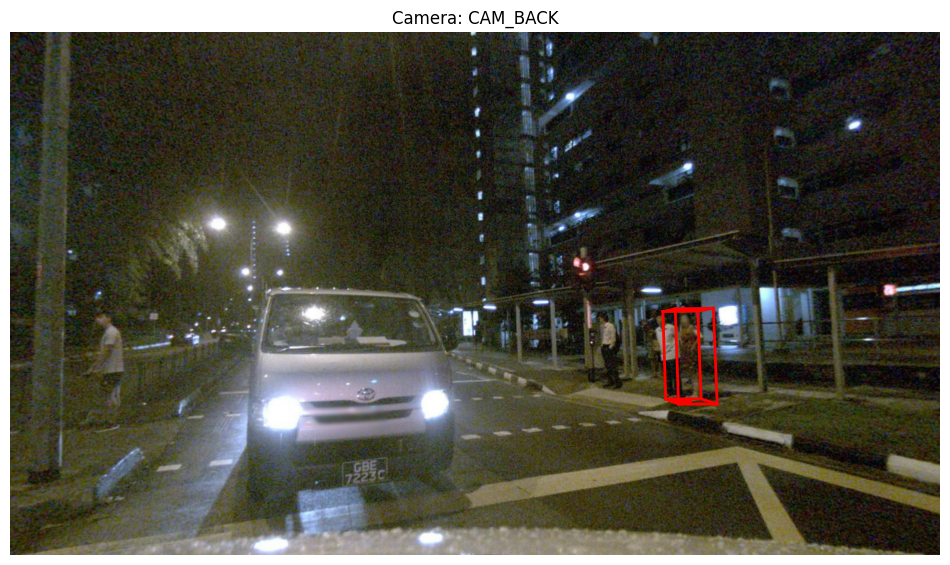

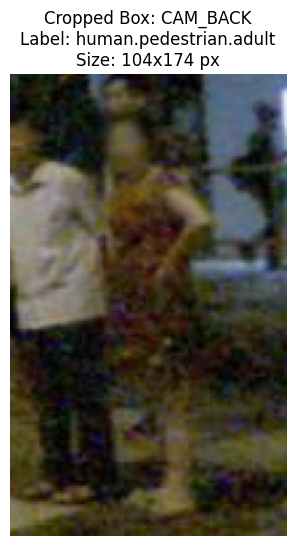

Cropped Image Size: (104, 174)


In [7]:
cropped_im = crop_annotation_and_render(nusc, ann_token, sample_record, margin=5)
if cropped_im is not None:
    print("Cropped Image Size:", cropped_im.size)
else:
    print("Box mostly outside image. Skipping.")

In [8]:
cropped_im = crop_annotation(nusc, ann_token, sample_record, margin=5)
if cropped_im is not None:
    print("Cropped Image Size:", cropped_im.size)
else:
    print("Box mostly outside image. Skipping.")

type(cropped_im)

Cropped Image Size: (104, 174)


PIL.Image.Image